# Nuclear data uncertainty propagation using the SANDY API

This tutorial shows how to extract, process, and propagate nuclear data uncertainties using the SANDY Python library coupled with NJOY processing tools.

The workflow reflects a complete end‑to‑end path: from raw ENDF‑6 files to covariance sampling, to perturbation of evaluated data.

In [1]:
import sandy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


In [ ]:
Reading and Inspecting ENDF‑6 Data
We began by retrieving the JEFF‑3.3 evaluated nuclear data file for hydrogen‑1 (ZAM=10010) from the IAEA archive.
Basic ENDF content inspection (MF=3, MT=1, etc.) allowed us to verify that the cross sections were available and correctly formatted.
This step introduces:

The ZAM indexing convention
The internal structure of ENDF‑6 files as parsed by sandy

## Reading and Inspecting ENDF‑6 Data

We begin by retrieving the JEFF‑3.3 evaluated nuclear data file for hydrogen‑1 (ZAM=10010) from the **IAEA archive**.

Basic ENDF content inspection (MF=3, MT=1, etc.) allowed us to verify that the cross sections were available and correctly formatted.

> ZAM = Z $\times$ 10000 + A $\times$ 10 + M
> 
> - Z: charge number
> - A: mass number
> - M: metastate (0=ground state, 1=first metastate, ...)
> 
> For $^1$H, ZAM=10010
> 
> For $^{235}$U, ZAM=922350
> 
> For $^{242m}$Am, ZAM=952421

In [2]:
endf = sandy.get_endf6_file("jeff_33", "xs", 10010)

In [3]:
endf

MAT  MF  MT 
125  1   451     1.001000+3 9.991673-1          0          0  ...
     2   151     1.001000+3 9.991673-1          0          0  ...
     3   1       1.001000+3 9.991673-1          0          0  ...
         2       1.001000+3 9.991673-1          0          0  ...
         102     1.001000+3 9.991673-1          0          0  ...
     4   2       1.001000+3 9.991673-1          0          1  ...
     6   102     1.001000+3 9.991673-1          0          2  ...
     33  1       1.001000+3 9.991673-1          0          0  ...
         2       1.001000+3 9.991673-1          0          0  ...
         102     1.001000+3 9.991673-1          0          0  ...
dtype: object

In [4]:
print(endf.data[(125, 3, 1)])

 1.001000+3 9.991673-1          0          0          0          0 125 3  1    1
 0.000000+0 0.000000+0          0          0          2         96 125 3  1    2
         30          5         96          2                       125 3  1    3
 1.000000-5 3.713628+1 2.000000-5 3.224498+1 5.000000-5 2.790478+1 125 3  1    4
 1.000000-4 2.571732+1 2.000000-4 2.417056+1 5.000000-4 2.279806+1 125 3  1    5
 1.000000-3 2.210633+1 2.000000-3 2.161720+1 5.000000-3 2.118318+1 125 3  1    6
 1.000000-2 2.096443+1 2.530000-2 2.076834+1 5.000000-2 2.067250+1 125 3  1    7
 1.000000-1 2.060332+1 2.000000-1 2.055439+1 5.000000-1 2.051095+1 125 3  1    8
 1.000000+0 2.048901+1 2.000000+0 2.047341+1 5.000000+0 2.045928+1 125 3  1    9
 1.000000+1 2.045169+1 2.000000+1 2.044545+1 5.000000+1 2.043707+1 125 3  1   10
 1.000000+2 2.042815+1 2.000000+2 2.041317+1 5.000000+2 2.037161+1 125 3  1   11
 1.000000+3 2.030435+1 2.000000+3 2.017221+1 4.000000+3 1.991433+1 125 3  1   12
 6.000000+3 1.966407+1 8.000

## Extract cross section data

We reconstructed tabulated **pointwise cross sections** from resonance parameters.

This is done runnning the **RECONR** module of **NJOY**.

The output is a PENDF file, which contains:
 - Linearized cross sections
 - Reconstructed resonance region
 - Continuous energy grid

A 0.1% linearization tolerance (see parameter `err`) is used too speed-up calculations!

In [5]:
pendf = endf.get_pendf(err=0.1, verbose=True)

get_pendf | ZAM=10010 | augmented NJOY kwargs: { 'acer': False,
  'broadr': False,
  'broadr_kws': {'err': 0.1},
  'dryrun': False,
  'gaspr': False,
  'heatr': False,
  'purr': False,
  'reconr_kws': {'err': 0.1},
  'temperatures': [0],
  'thermr': False,
  'thermr_kws': {'err': 0.1},
  'unresr': False}
get_pendf | ZAM=10010 | run NJOY
_run_njoy | ZAM=10010 | NJOY ran in 1.220 s
get_pendf | ZAM=10010 | parsing NJOY PENDF output into Endf6 structure


Extract the cross sections from the PENDF file and plot them to provide an overview of the $\sigma(E)$ behavior for several MT reactions.

In [6]:
xs = sandy.Xs.from_endf6(pendf)

<Axes: xlabel='E'>

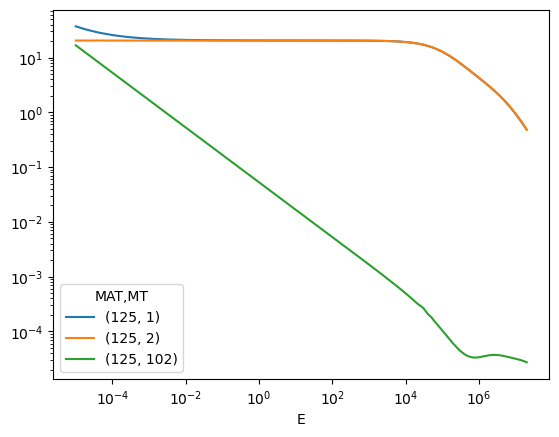

In [7]:
xs.data.plot(logx=True, logy=True)

## Extract covariance data

Covariance data are contained in the ENDF-6 file, but they must be processed to:
- have a unique multi-group structure for all reactions
- reconstruct covariance data when partial contributions are given, e.g., background uncertainty + other uncertainties
- impose constraints if given (total = $\sum$partial)

This is done with **NJOY** (module **ERRORR**) and requires:
- group structure (see parameter `ign`)
- approximate neutron spectrum (see parameter `iwt`)

The output is a ERRORR file.
Then, extract the covariance matrix from the ERRORR file. 

In [8]:
errorrs = endf.get_errorr(verbose=True, err=0.1, errorr33_kws=dict(ign=4))

get_errorr | ZAM=10010 | loaded ENDF records: MF present = [ 1  2  3  4  6 33]
get_errorr | ZAM=10010 | augmenting ERRORR NJOY kwargs
get_errorr | ZAM=10010 | augmenting GROUPR NJOY kwargs
get_errorr | ZAM=10010 | covariance availability: MF31=False MF33=True MF34=False MF35=False
get_errorr | ZAM=10010 | covariance processing: MF31=False MF33=True MF34=False MF35=False
get_errorr | ZAM=10010 | running NJOY with augmented kwargs: { 'acer': False,
  'broadr': False,
  'broadr_kws': {'err': 0.1},
  'dryrun': False,
  'errorr31': False,
  'errorr31_kws': {},
  'errorr33': True,
  'errorr33_kws': {'ign': 4},
  'errorr34': False,
  'errorr34_kws': {},
  'errorr35': False,
  'errorr35_kws': {},
  'gaspr': False,
  'groupr_kws': {'chi': False, 'mubar': True, 'nubar': False},
  'heatr': False,
  'purr': False,
  'reconr_kws': {'err': 0.1},
  'temperatures': [0],
  'thermr': False,
  'thermr_kws': {'err': 0.1},
  'unresr': False}
get_errorr | ZAM=10010 | run NJOY
_run_njoy | ZAM=10010 | NJOY ra

In [9]:
cov = errorrs["errorr33"].get_cov()

### Plot the multigroup energy structure of the covariance matrix

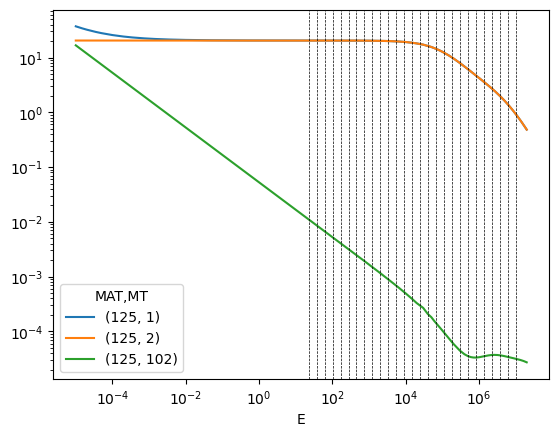

In [10]:
xs.data.plot(logx=True, logy=True)
plt.vlines(cov.data.index.get_level_values("E").right.unique(), ymin=0, ymax=100, color="k", ls="--", lw=.5)

### Plot the correlation matrix

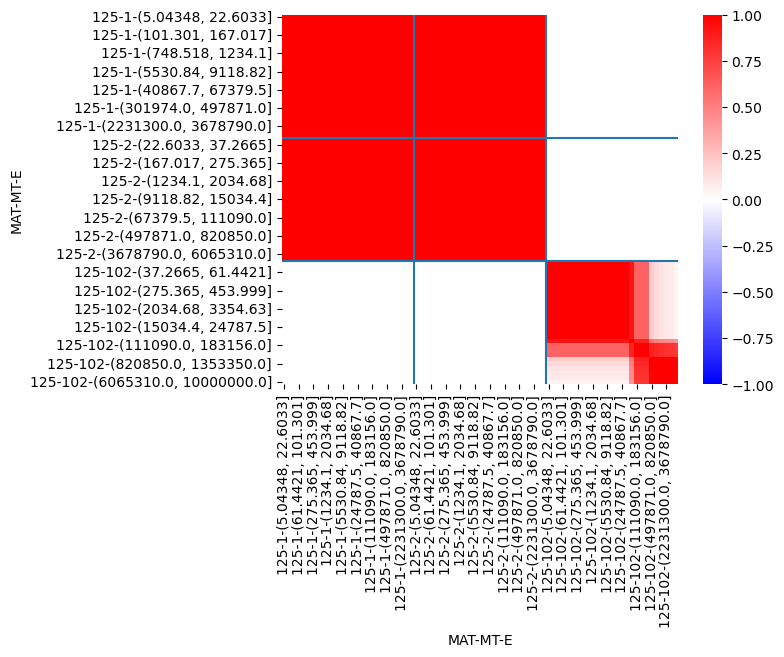

In [11]:
sns.heatmap(data=cov.get_corr().data, vmin=-1, vmax=1, cmap="bwr")
plt.axvline(27)
plt.axhline(27)
plt.axvline(27 * 2)
plt.axhline(27 * 2)

### Plot the standard deviation

In [ ]:
std = cov.get_std().reset_index().pivot_table(index="E", columns="MT", values="STD")
std.index = std.index.right
std.plot(drawstyle="steps-pre", logx=True)

<Axes: >

## Draw sample of PDF with given covariance matrix

Nuclear data covariance matrices are in relative terms (divide by the mean). Then the PDF is centered in one.

Random variable: $\frac{X}{E[X]}$

Mean value: $E\left[\frac{X}{E[X]}\right]=1$

Variance: $Var\left(\frac{X}{E[X]}\right) = E\left[\left(\frac{X}{E[X]}-1\right)^2\right] = E\left[\left(\frac{X-E[X]}{E[X]}\right)^2\right] = \frac{E\left[\left(X-E[X]\right)^2\right]}{E[X]^2}=\frac{Var(X)}{E[X]^2} \; \xRightarrow{\sqrt{}} \; \frac{\sigma_X}{\mu_X}$

Take a sample of size $N=10000$. Make it reproducible by fixing the seed.

In [14]:
smp = cov.sampling(10000, seed=1)

### Plot the sample estimate of the correlation matrix

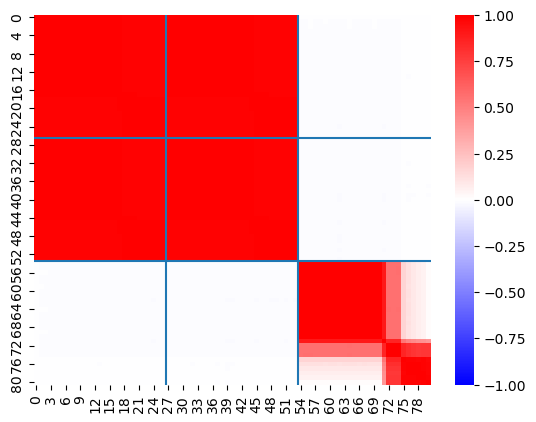

In [15]:
sns.heatmap(np.corrcoef(smp.data.iloc[:, :]), vmin=-1, vmax=1, cmap='bwr')
plt.axvline(27)
plt.axhline(27)
plt.axvline(27 * 2)
plt.axhline(27 * 2)

### Plot the sample estimate of the standard deviation

<Axes: >

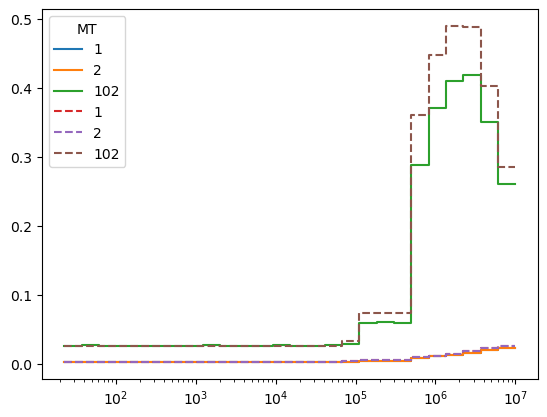

In [16]:
sstd = smp.data.iloc[:, :50].std(axis=1).rename("STD").reset_index().pivot_table(index="E", columns="MT", values="STD")
sstd.index = sstd.index.right
ax = sstd.plot(drawstyle="steps-pre", logx=True)
std.plot(drawstyle="steps-pre", ls="--", logx=True, ax=ax)

### Plot the sample estimate of the PDF

<Axes: xlabel='vals', ylabel='Count'>

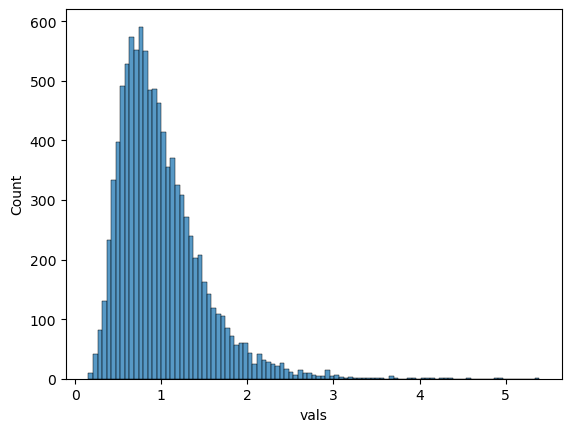

In [17]:
sns.histplot(smp.data.query("MT==102").stack().rename("vals").reset_index().groupby(["SMP"]).nth(-3), x="vals")

## Multi-group perturbation vs continuous energy data

In [18]:
s = smp.data[5].reset_index().pivot_table(index="E", columns=["MAT", "MT"], values=5)

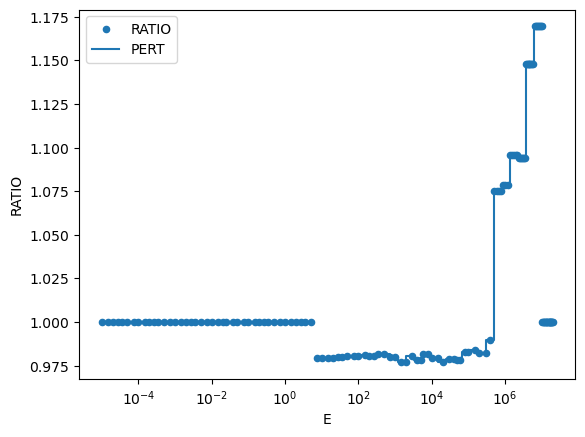

In [19]:
xs0 = xs._perturb(s)
(xs0.data / xs.data)[125, 102].rename("RATIO").reset_index().plot.scatter(x="E", y="RATIO", logx=True, label="RATIO")
plt.plot(s.index.right, s[(125, 102)], drawstyle="steps-pre", label="PERT")
plt.legend()

## Wrap it up in two steps

Create a sample (size $N=20$) from the multi-group relative covariance matrix of $^1$H cross sections. Then store these perturbations in a excel file.

In [20]:
smps = endf.get_perturbations(20, verbose=True)

########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_xs | ZAM=10010 | run ERRORR via get_errorr({'mubar': False, 'njoy_output': -3})
get_perturbations_xs | ZAM=10010 | covariance MFs available=[33]
get_perturbations_xs | ZAM=10010 | MF=33 | writing ERRORR -> 'C:\Users\lfiorito\OneDrive - Studiecentrum voor Kernenergie\Documents\sandy\notebooks\exercise\ERRORR_1001_MF33.tape'
get_perturbations_xs | ZAM=10010 | MF=33 | file exists and will be overwritten
get_perturbations_xs | ZAM=10010 | MF=33 | extracting covariance matrix
get_perturbations_xs | ZAM=10010 | MF=33 | covariance matrix size=(720, 720)
get_perturbations_xs | ZAM=10010 | MF=33 | found MT numbers=[  1   2 102]
get_perturbations_xs | ZAM=10010 | MF=33 | explicit seed not provided
get_perturbations_xs | ZAM=10010 | MF=33 | sampling with SMP size=20 via sampling(seed=122551222021577031760603471

Convert the multi-group perturbations into random ENDF-6 files.

In [21]:
outs = endf.apply_perturbations(smps, to_file=True, verbose=True)

########################################################
              APPLY PERTURBATIONS                       
########################################################
apply_perturbations_xs | ZAM=10010 | kinds={33} | SMP size=20
apply_perturbations_xs | ZAM=10010 | PENDF=generated via get_pendf({'njoy_output': -3})
apply_perturbations_xs | ZAM=10010 | mode=serial


XS perturbations:   0%|                                                                             | 0/20 [00…

[PID 18732] XS-worker | sample=   0 | ZAM=10010 | (NU=False, XS=True, PFNS=False) | start
[PID 18732] XS-worker | sample=   0 | ZAM=10010 | writing to file
[PID 18732] WRITE-worker | sample=   0 | ZAM=10010 | writing ENDF-6 to file -> '1001_0.endf6'
[PID 18732] WRITE-worker | sample=   0 | ZAM=10010 | Writing PENDF to file -> '1001_0.pendf'
[PID 18732] XS-worker | sample=   0 | ZAM=10010 | finished in 0.195 s
[PID 18732] XS-worker | sample=   1 | ZAM=10010 | (NU=False, XS=True, PFNS=False) | start
[PID 18732] XS-worker | sample=   1 | ZAM=10010 | writing to file
[PID 18732] WRITE-worker | sample=   1 | ZAM=10010 | writing ENDF-6 to file -> '1001_1.endf6'
[PID 18732] WRITE-worker | sample=   1 | ZAM=10010 | Writing PENDF to file -> '1001_1.pendf'
[PID 18732] XS-worker | sample=   1 | ZAM=10010 | finished in 0.367 s
[PID 18732] XS-worker | sample=   2 | ZAM=10010 | (NU=False, XS=True, PFNS=False) | start
[PID 18732] XS-worker | sample=   2 | ZAM=10010 | writing to file
[PID 18732] WRITE-

# Exercise 1

Propagate the $^1$H covariance matrix through the model below using:
- the sandwich formula
- Monte Carlo sampling

Model:

$$y=\sum_{i=1}^M i\; x_i = 1 \times x_1 + 2 \times x_2 + 3 \times x_3 + \cdots + M \times x_M$$

Mean vector:
$$\boldsymbol{\mu}_{X}=\left[1, 1, \cdots, 1 \right]^T$$

Sensitivity vector:
$$\boldsymbol{S}=\left[1, 2, \cdots, M \right]^T$$

Vector notation:
$$y=\boldsymbol{S}^T \boldsymbol{x}$$

In [22]:
S = np.arange(smp.data.shape[0])
mu = np.ones_like(S)

In [23]:
model = lambda x: S @ x

In [24]:
model(mu)

np.int64(3240)

In [25]:
np.sqrt(S @ cov.data.values @ S)

np.float64(212.13866880602197)

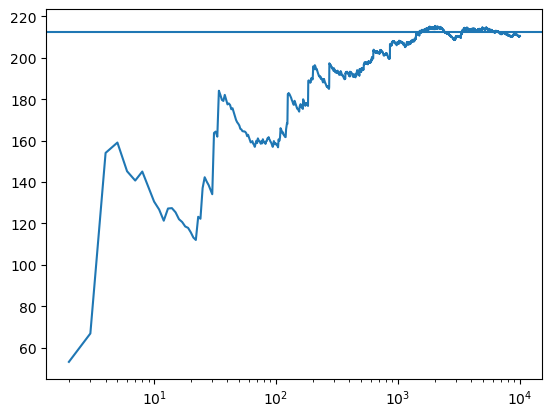

In [26]:
outs = np.array(list(map(model, smp.data.values.T)))
pd.Series({i: outs[:i].std() for i in range(2, outs.size)}).plot(logx=True)
plt.axhline(212.13866)

# Tutorial: nuclear data uncertainty propagation using SANDY

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sandy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Read ENDF-6 file

Retrieve JEFF-3.3 nuclear data evaluated file for $^1$H from the IAEA archives.

ZAM = Z $\times$ 10000 + A $\times$ 10 + M

- Z: charge number
- A: mass number
- M: metastate (0=ground state, 1=first metastate, ...)

For $^1$H, ZAM=10010

For $^{235}$U, ZAM=922350

For $^{242m}$Am, ZAM=952421

endf = sandy.get_endf6_file("jeff_33", "xs", 10010)

endf

print(endf.data[(125, 3, 1)])

## Extract xs data

Reconstruct pointwise tabulated cross section data from resonance parameters and linearize cross section within a given tolerance (see parameter `err`).

This is done with **NJOY** (module RECONR)!!!

The output is a PENDF file.

pendf = endf.get_pendf(err=0.1, verbose=True)

Extract the cross sections from the PENDF file and plot them.

xs = sandy.Xs.from_endf6(pendf)

xs.data.plot(logx=True, logy=True)

## Extract covariance data

Covariance data are contained in the ENDF-6 file, but they must be processed to:
- have a unique multi-group structure for all reactions
- reconstruct covariance data when partial contributions are given, e.g., background uncertainty + other uncertainties
- impose constraints if given (total = $\sum$partial)

This is done with **NJOY** (module ERRORR) and requires:
- group structure (see parameter `ign`)
- approximate neutron spectrum (see parameter `iwt`)

The output is a ERRORR file. Then, extract the covariance matrix from the ERRORR file. 

errorrs = endf.get_errorr(verbose=True, err=0.1, errorr33_kws=dict(ign=4))

cov = errorrs["errorr33"].get_cov()

### Plot the multigroup energy structure of the covariance matrix

xs.data.plot(logx=True, logy=True)
plt.vlines(cov.data.index.get_level_values("E").right.unique(), ymin=0, ymax=100, color="k", ls="--", lw=.5)

### Plot the correlation matrix

sns.heatmap(data=cov.get_corr().data, vmin=-1, vmax=1, cmap="bwr")
plt.axvline(27)
plt.axhline(27)
plt.axvline(27 * 2)
plt.axhline(27 * 2)

### Plot the standard deviation

std = cov.get_std().reset_index().pivot_table(index="E", columns="MT", values="STD")
std.index = std.index.right
std.plot(drawstyle="steps-pre", logx=True)

## Draw sample of PDF with given covariance matrix

Nuclear data covariance matrices are in relative terms (divide by the mean). Then the PDF is centered in one.

Random variable: $\frac{X}{E[X]}$

Mean value: $E\left[\frac{X}{E[X]}\right]=1$

Variance: $Var\left(\frac{X}{E[X]}\right) = E\left[\left(\frac{X}{E[X]}-1\right)^2\right] = E\left[\left(\frac{X-E[X]}{E[X]}\right)^2\right] = \frac{E\left[\left(X-E[X]\right)^2\right]}{E[X]^2}=\frac{Var(X)}{E[X]^2} \; \xRightarrow{\sqrt{}} \; \frac{\sigma_X}{\mu_X}$

Take a sample of size $N=10000$. Make it reproducible by fixing the seed.

smp = cov.sampling(10000, seed=1)

### Plot the sample estimate of the correlation matrix

sns.heatmap(np.corrcoef(smp.data.iloc[:, :]), vmin=-1, vmax=1, cmap='bwr')
plt.axvline(27)
plt.axhline(27)
plt.axvline(27 * 2)
plt.axhline(27 * 2)

### Plot the sample estimate of the standard deviation

sstd = smp.data.iloc[:, :50].std(axis=1).rename("STD").reset_index().pivot_table(index="E", columns="MT", values="STD")
sstd.index = sstd.index.right
ax = sstd.plot(drawstyle="steps-pre", logx=True)
std.plot(drawstyle="steps-pre", ls="--", logx=True, ax=ax)

### Plot the sample estimate of the PDF

sns.histplot(smp.data.query("MT==102").stack().rename("vals").reset_index().groupby(["SMP"]).nth(-3), x="vals")

## Multi-group perturbation vs continuous energy data

s = smp.data[5].reset_index().pivot_table(index="E", columns=["MAT", "MT"], values=5)

xs0 = xs._perturb(s)
(xs0.data / xs.data)[125, 102].rename("RATIO").reset_index().plot.scatter(x="E", y="RATIO", logx=True, label="RATIO")
plt.plot(s.index.right, s[(125, 102)], drawstyle="steps-pre", label="PERT")
plt.legend()

## Wrap it up in two steps

Create a sample (size $N=20$) from the multi-group relative covariance matrix of $^1$H cross sections. Then store these perturbations in a excel file.

smps = endf.get_perturbations(20, verbose=True)

Convert the multi-group perturbations into random ENDF-6 files.

outs = endf.apply_perturbations(smps, to_file=True, verbose=True)

# Exercise 1

Propagate the $^1$H covariance matrix through the model below using:
- the sandwich formula
- Monte Carlo sampling

Model:

$$y=\sum_{i=1}^M i\; x_i = 1 \times x_1 + 2 \times x_2 + 3 \times x_3 + \cdots + M \times x_M$$

Mean vector:
$$\boldsymbol{\mu}_{X}=\left[1, 1, \cdots, 1 \right]^T$$

Sensitivity vector:
$$\boldsymbol{S}=\left[1, 2, \cdots, M \right]^T$$

Vector notation:
$$y=\boldsymbol{S}^T \boldsymbol{x}$$

S = np.arange(smp.data.shape[0])
mu = np.ones_like(S)

model = lambda x: S @ x

model(mu)

np.sqrt(S @ cov.data.values @ S)

outs = np.array(list(map(model, smp.data.values.T)))
pd.Series({i: outs[:i].std() for i in range(2, outs.size)}).plot(logx=True)
plt.axhline(212.13866)